In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from utils import *
from plots import *
import pandas as pd
idx = pd.IndexSlice
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt 

### Get Dateset

In [2]:
# get the dataset - stance normalized step data for 26 subjects (mean step for each subject and speed)
# data is a DataFrame with columns: subject, speed, metric, joint, dimension
# subject: subject id
# speed: running speed (8-13 km/h)   
# metric: moments, force
# joint: ankle, knee, hip, (force)
# dimension: sagittal, frontal, transverse, vertical, antero-posterior, medio-lateral
data = get_dataset()

100%|██████████| 156/156 [00:36<00:00,  4.29it/s]


In [3]:
# group dataset by conditions (joint, dimension)  e.g. ankle sagittal, ankle frontal, ankle transverse, ...
data_grouped = data.T.groupby(level=[3, 4])
conditions = data_grouped.groups.keys()
speeds = sorted(data.columns.get_level_values("speed").unique())

### SPM Statistics (RM-ANOVA & paired t-test)

In [4]:
# perform spm1d analysis for each condition
spm_dict = {}
for condition in conditions:
    # get condition and drop unnecessary index levels
    data_cond = data_grouped.get_group(condition)
    data_cond.index = data_cond.index.droplevel([2,3,4])

    # get means across subjects for each speed
    means = {speed: data_cond.loc[idx[:,speed],:].mean(axis=0) for speed in speeds}

    # perfrom RM ANOVA
    anova_results = rm_anova(data_cond, speeds)

    # perform post-hoc paired t-tests
    post_hoc_results = post_hoc(data_cond, speeds)

    # store results
    spm_dict[condition] = {"means": means, 
                           "anova": anova_results, 
                           "posthoc": post_hoc_results}

### Plot Results

##### Mean /w Significant Regions

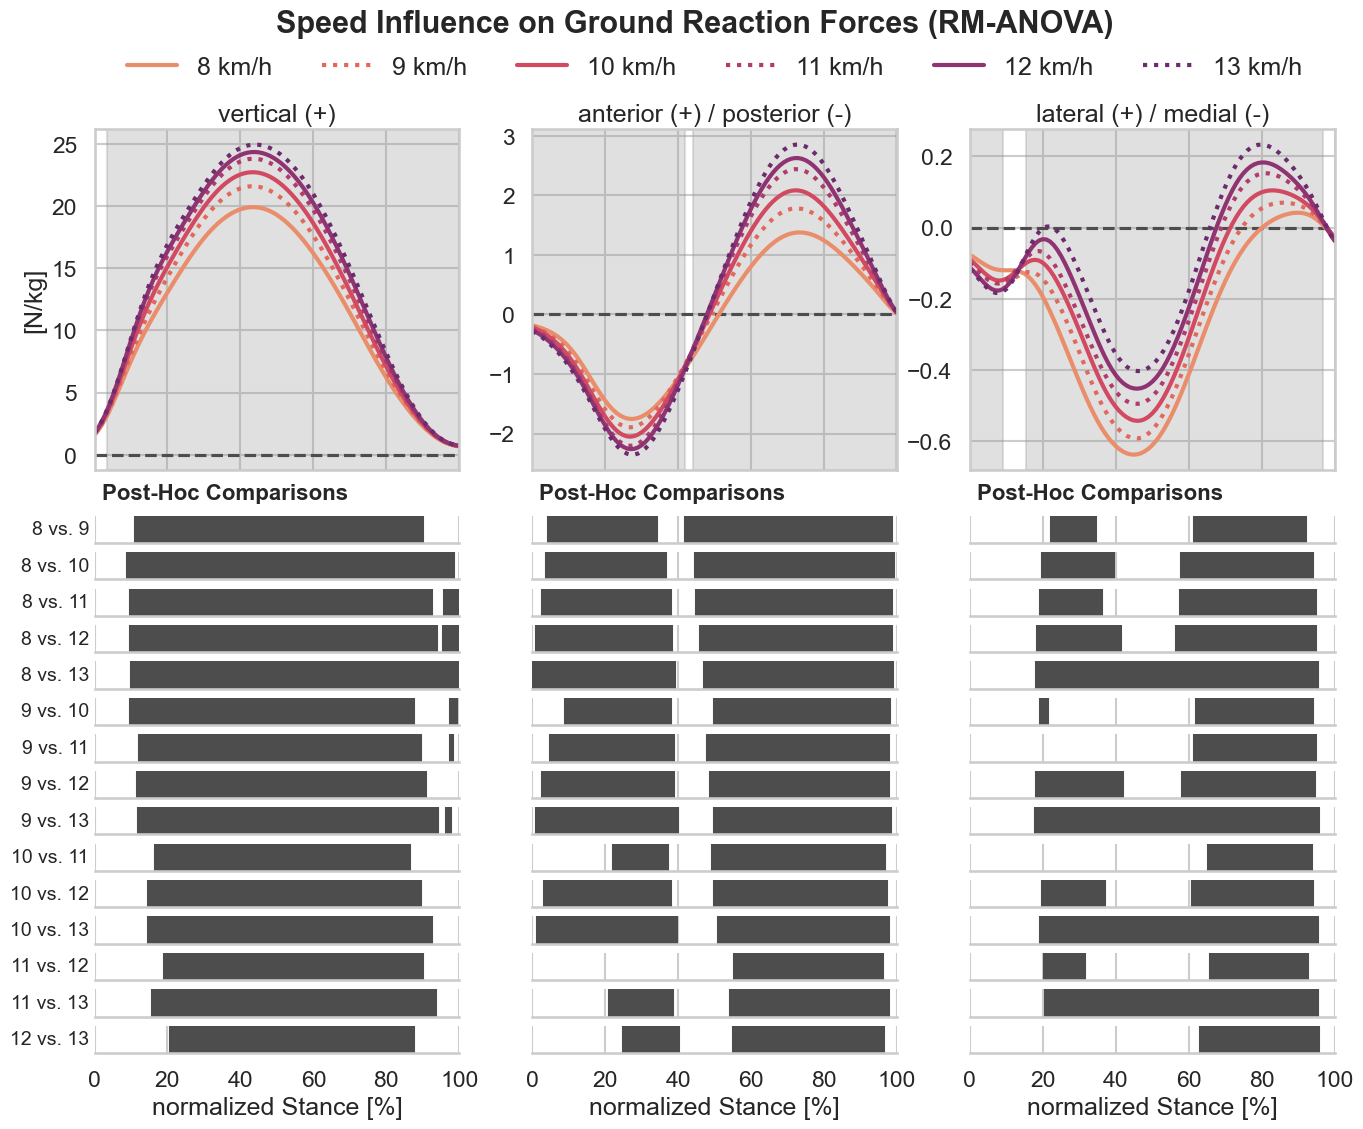

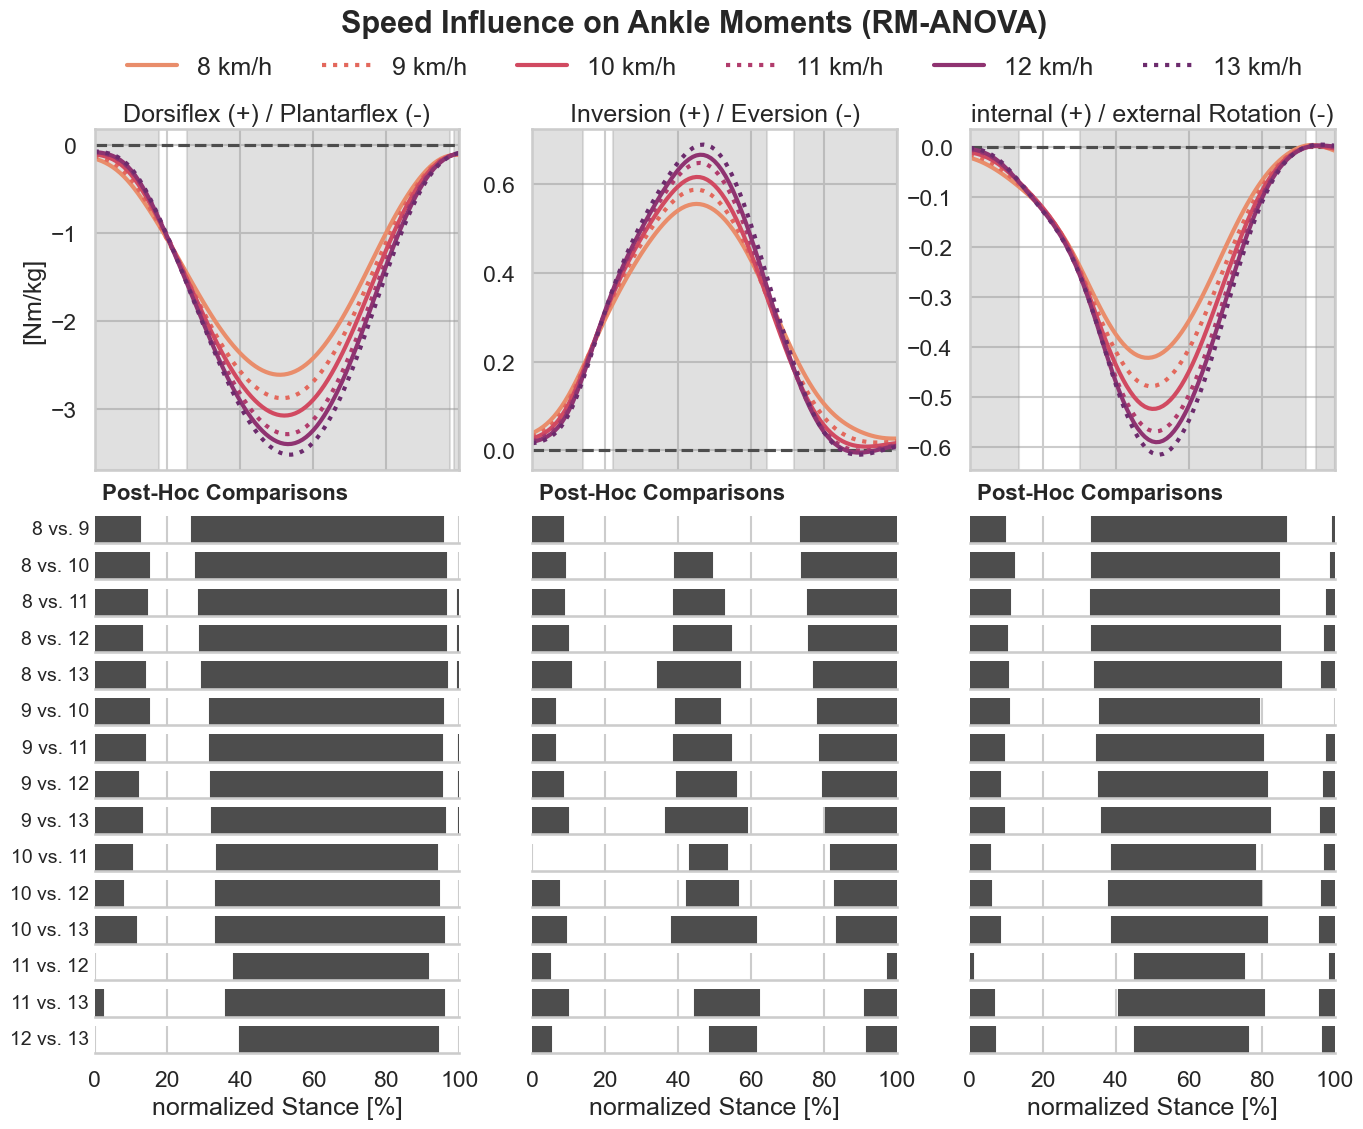

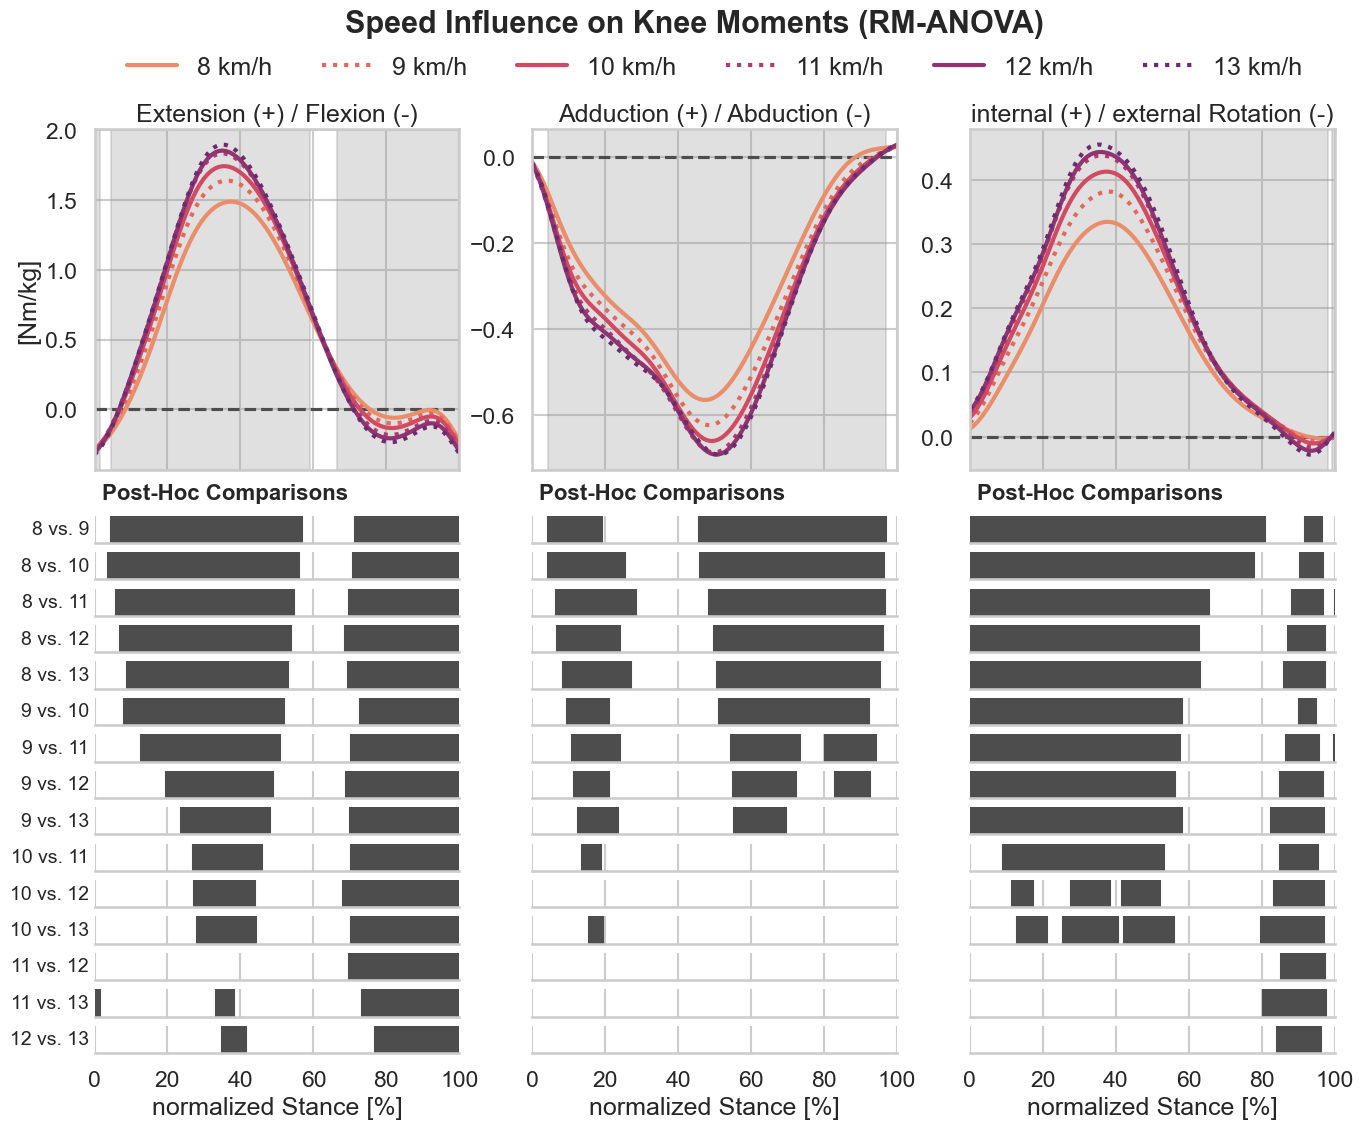

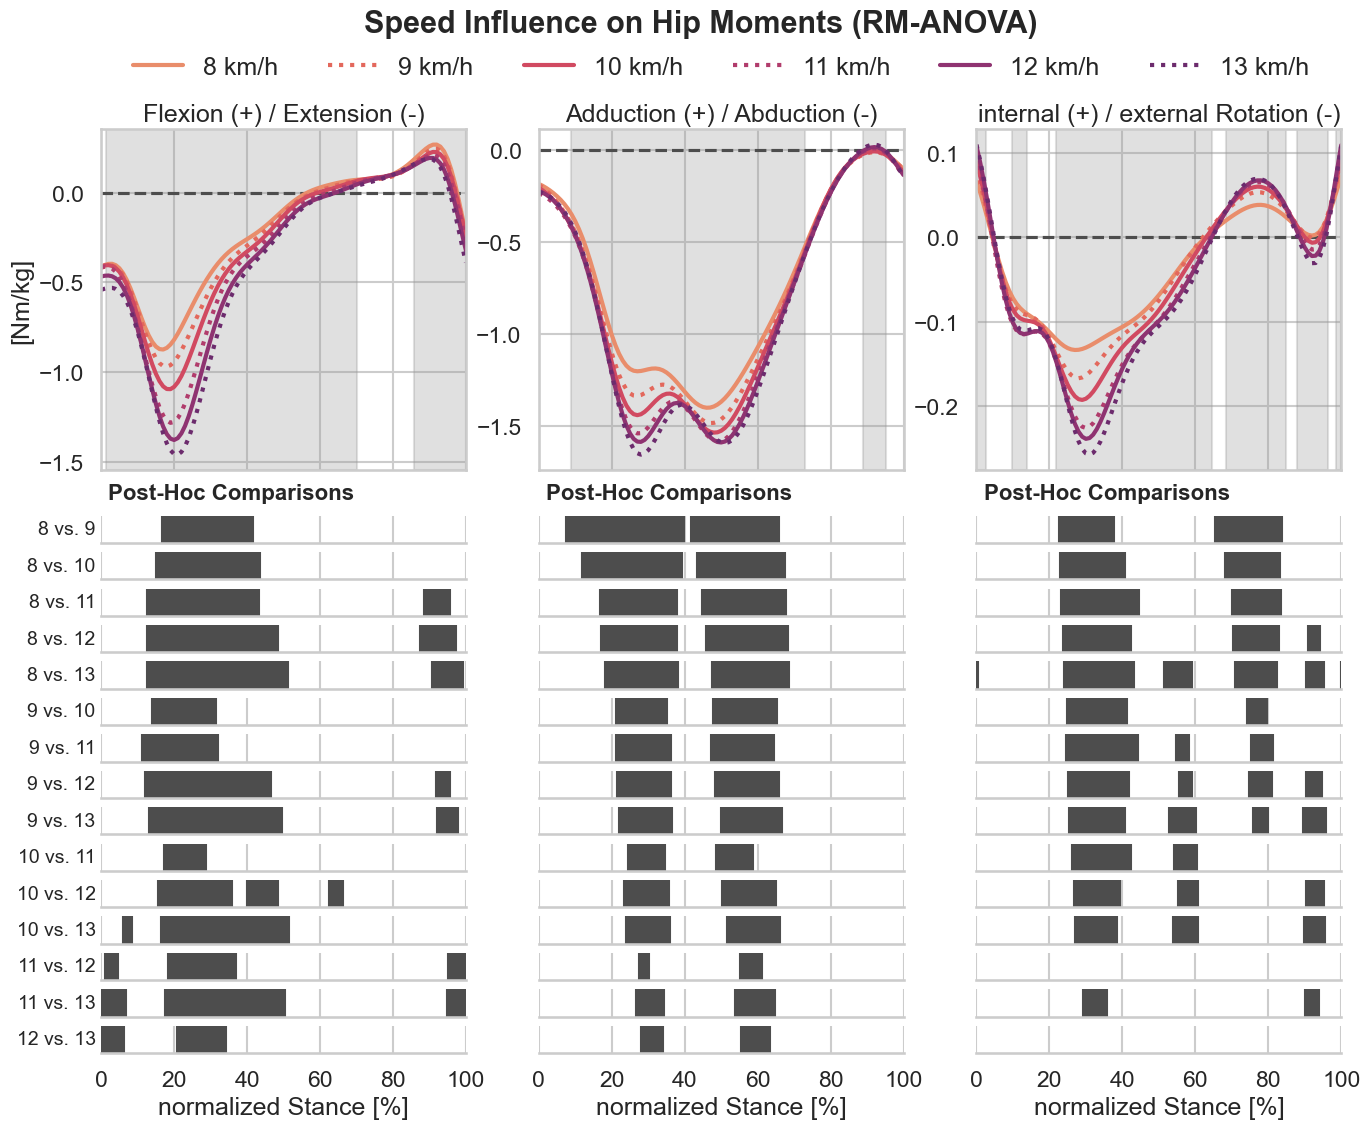

In [5]:
# plot results - Means & shaded bars for significant regions
mean_plot(spm_dict)

##### Continuous SPM Test Values

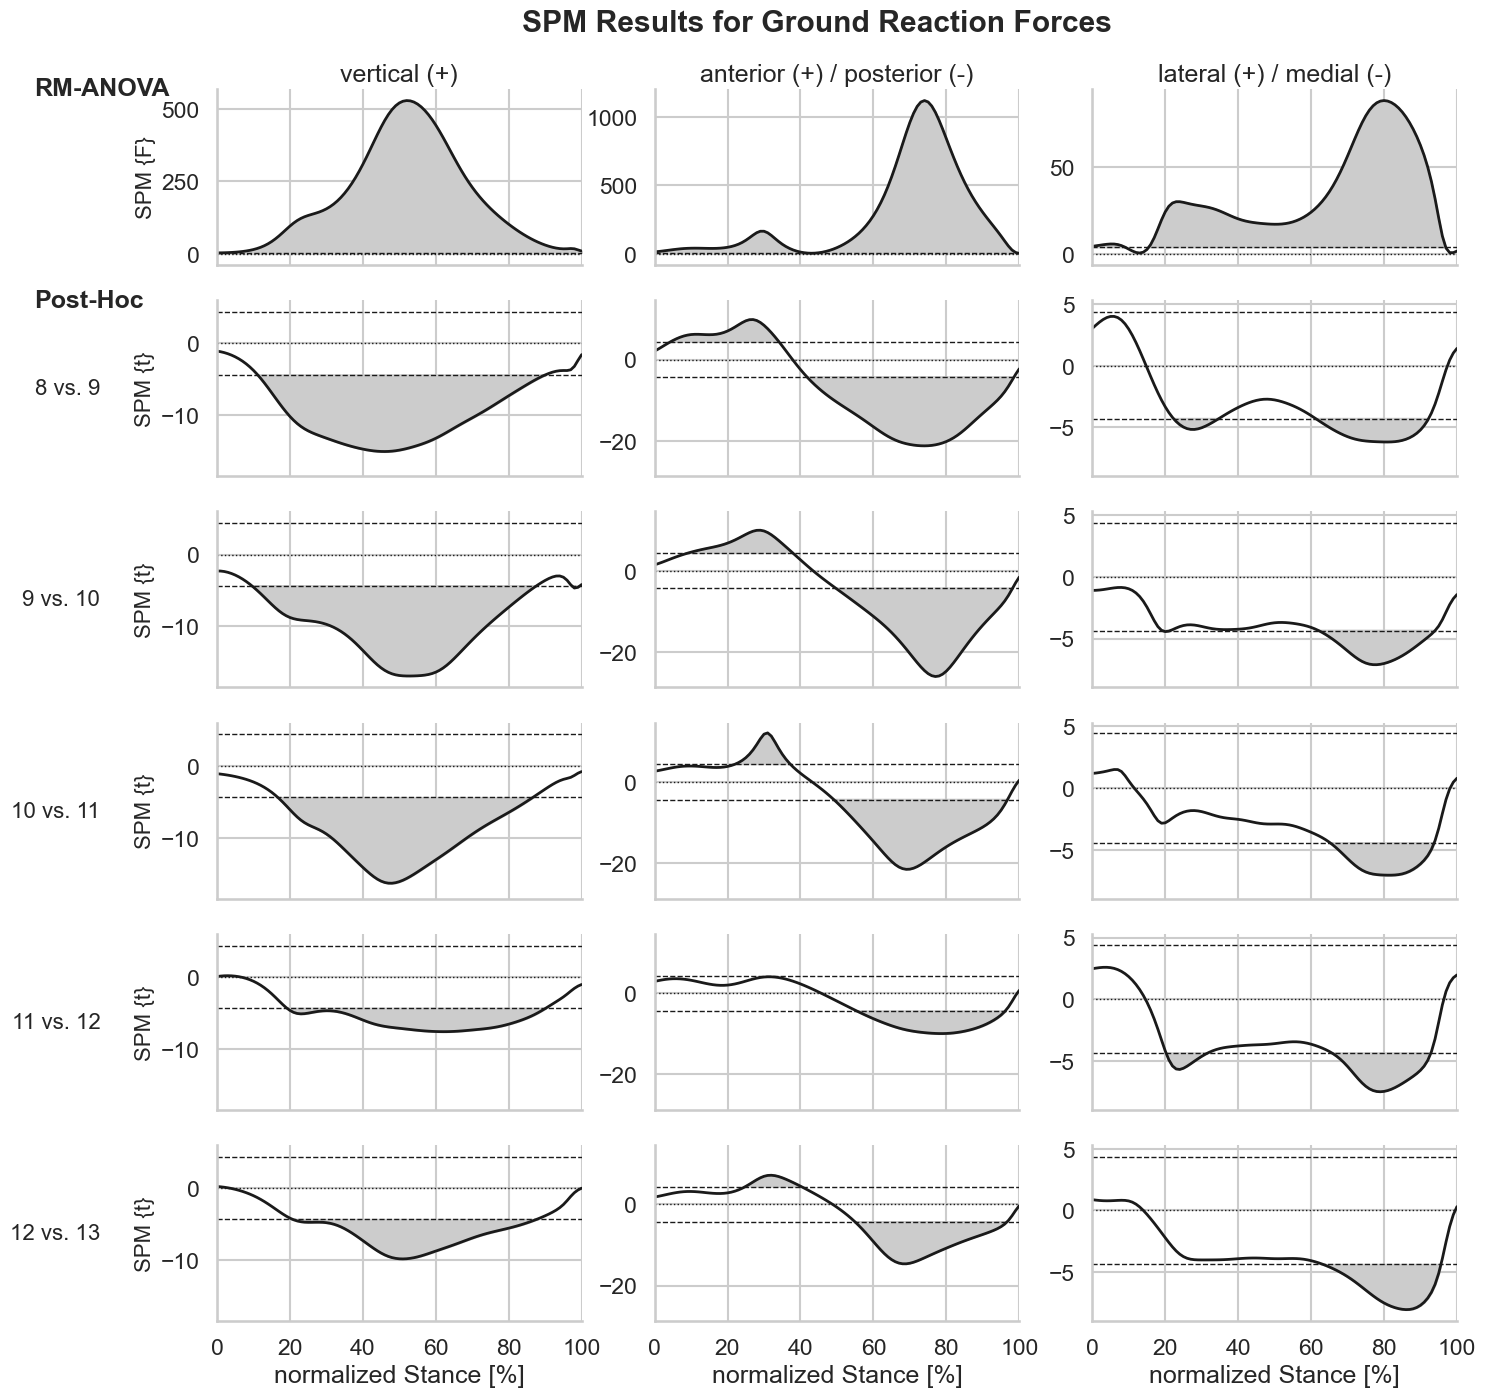

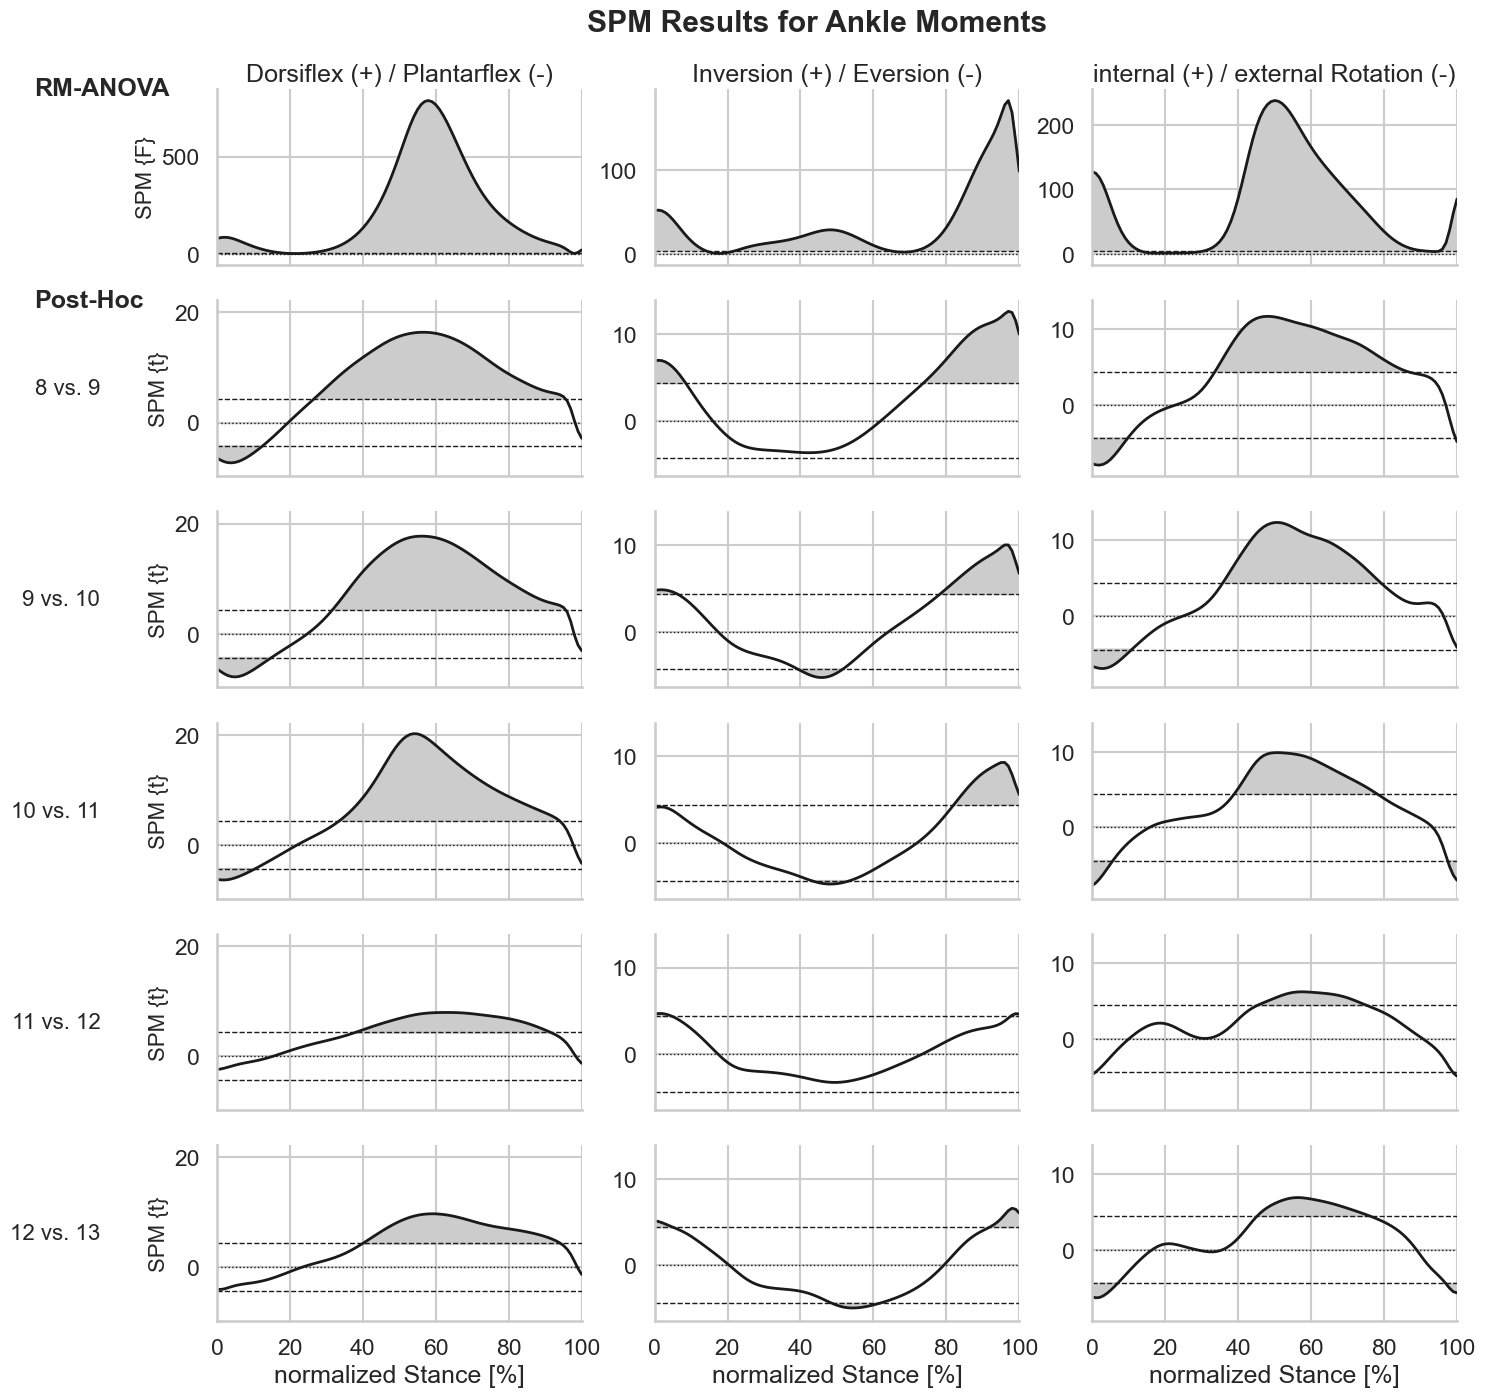

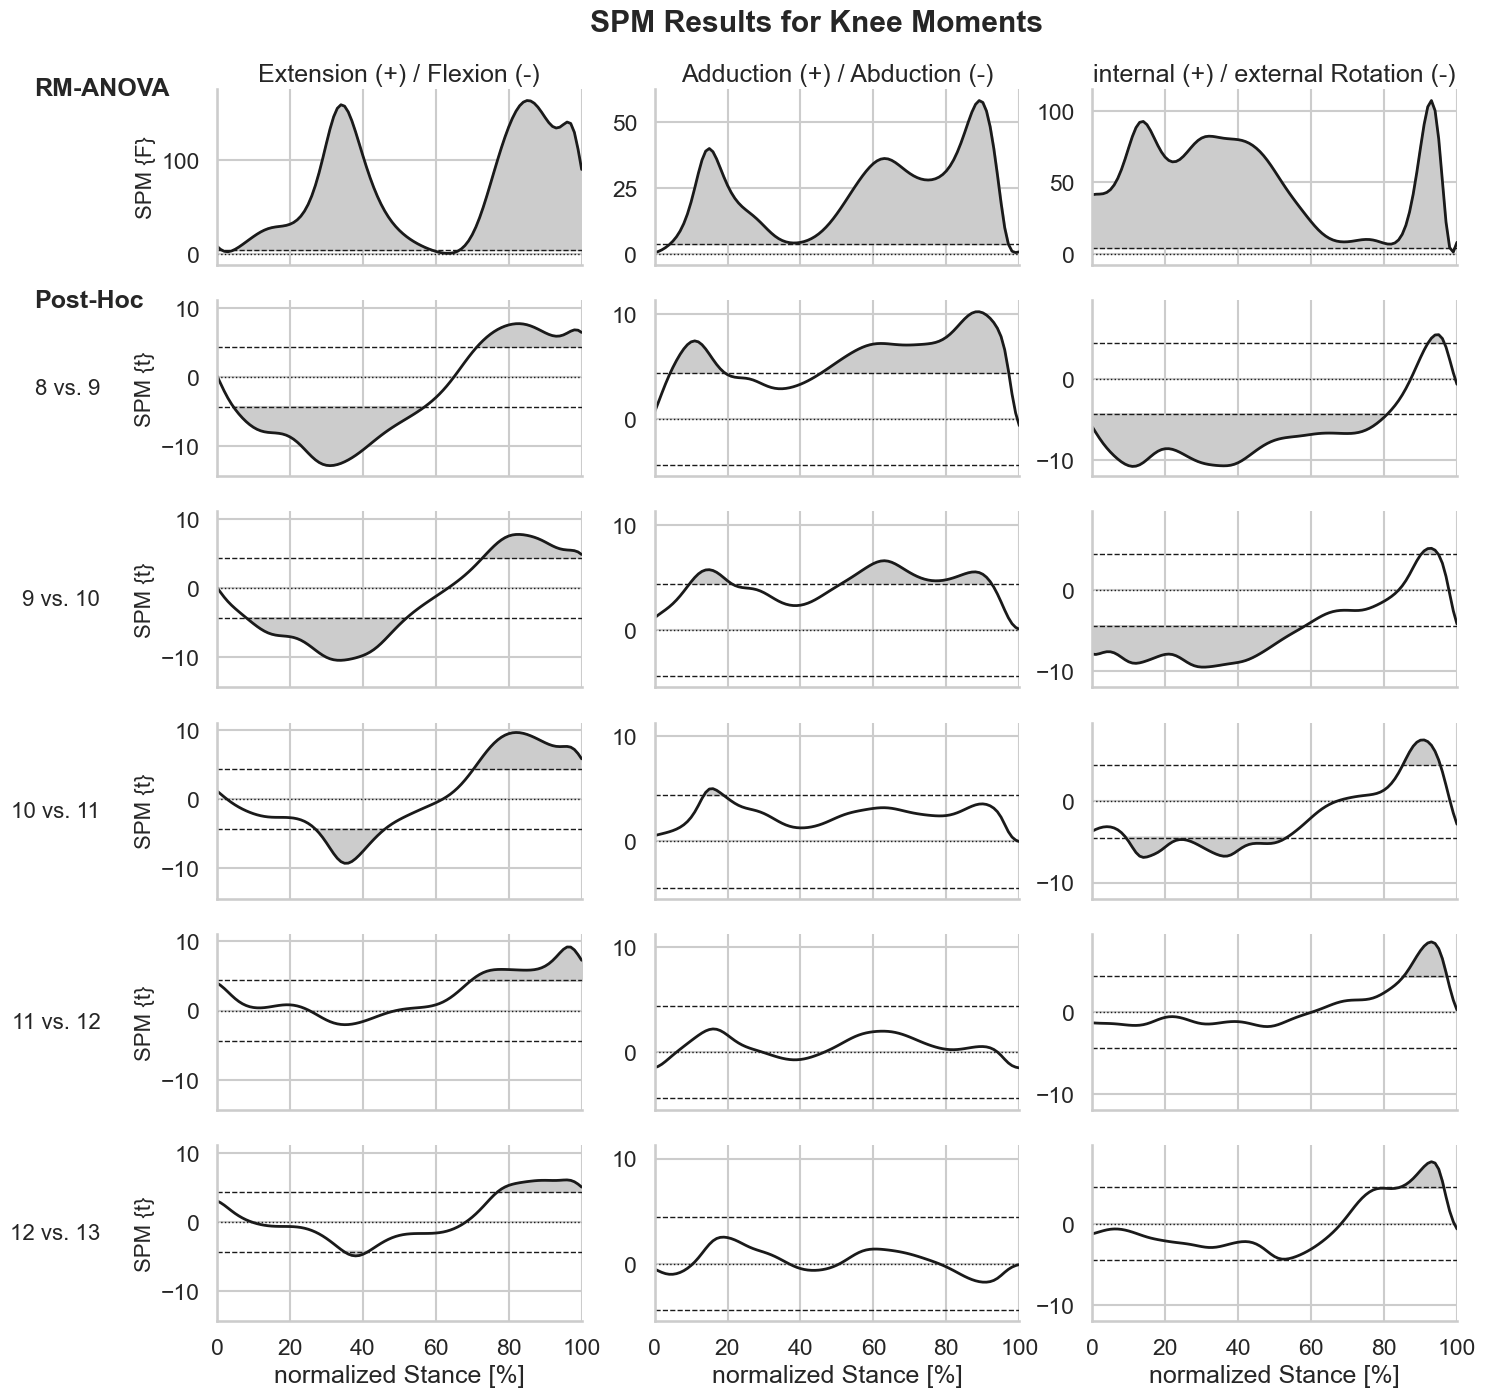

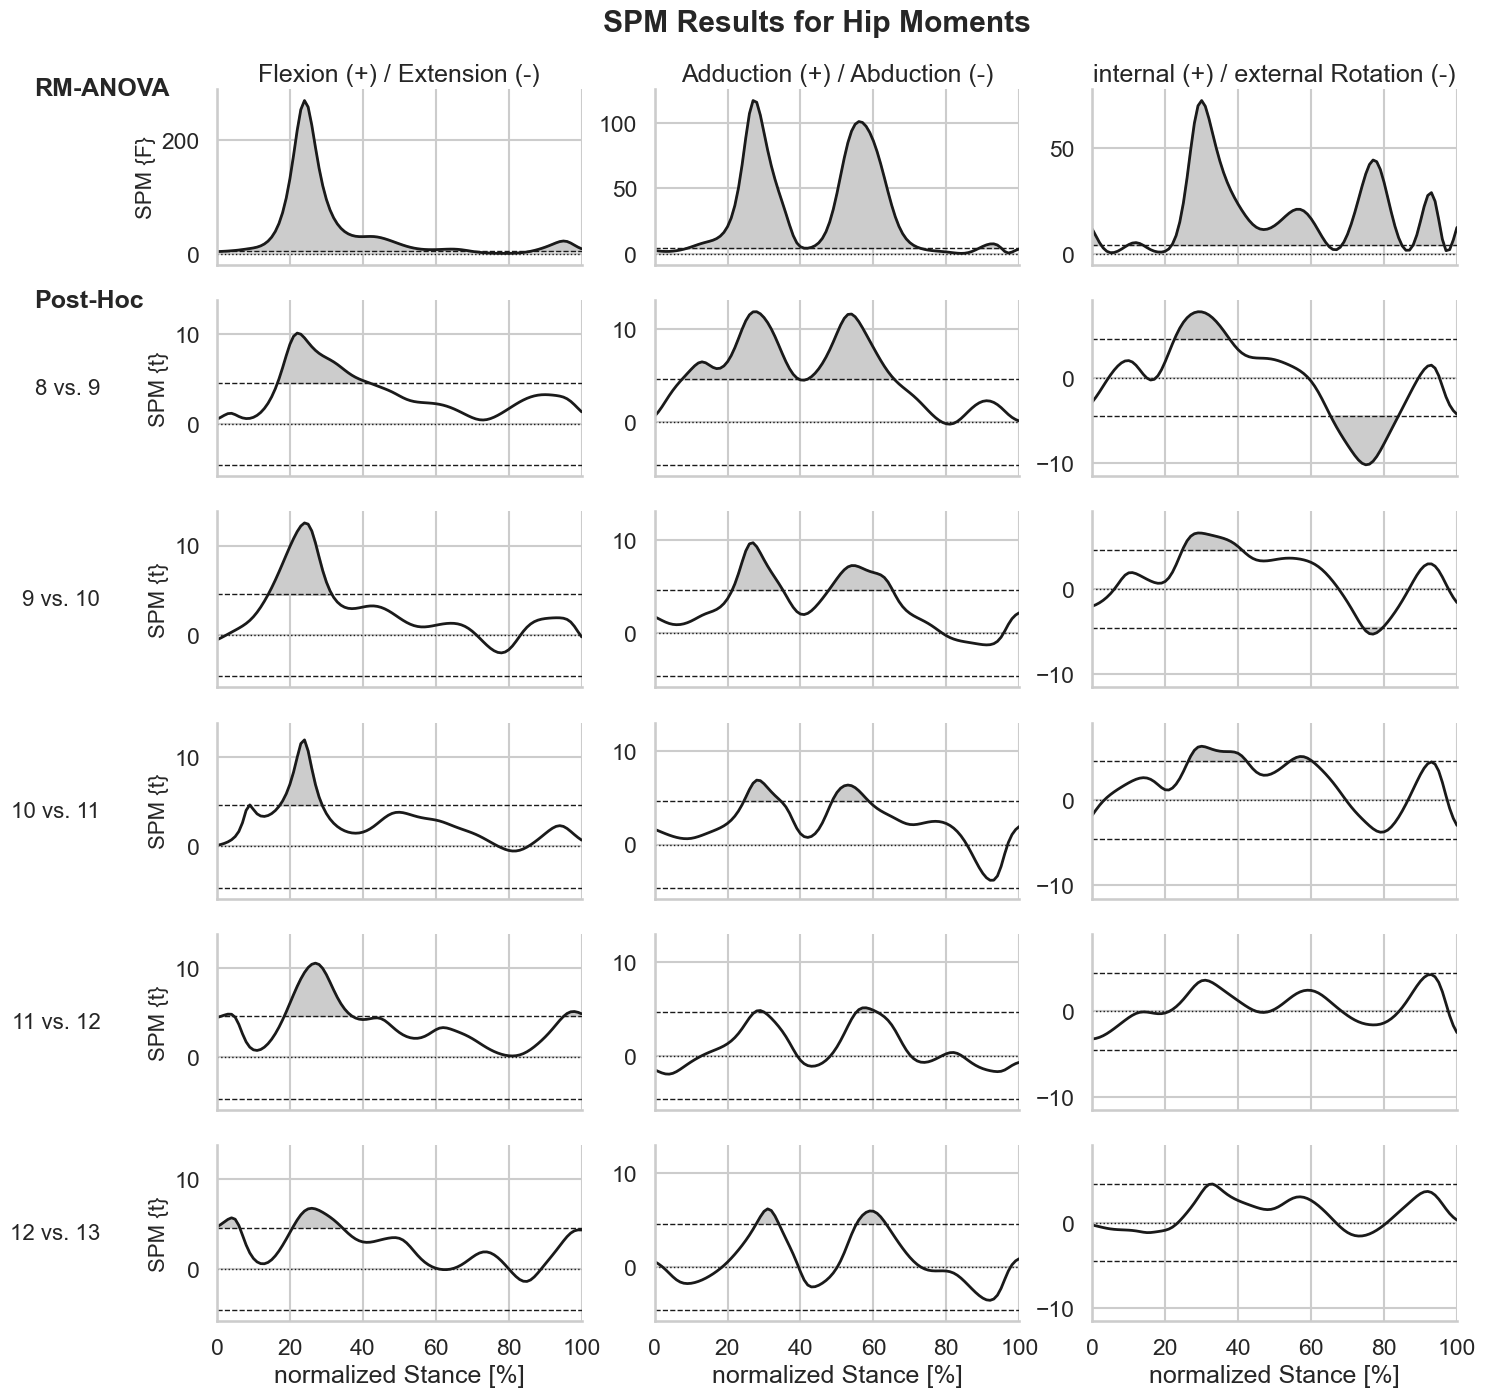

In [6]:
# plot results - actual continuous F and t-values
spm_value_plot(spm_dict)